# 01. Frequency & Severity Models

## Objective
Understand and implement the Frequency-Severity structure.

## Core Concepts
- Frequency(N): How many claims occur in one year?
- Severity(X): How large is each individual claim?
- Aggregate Loss: S = X1 + X2 + ... + XN

## Why This Matters
Before an insurer can calculate how much capital to hold,
they must first understand how losses are distributed.
This notebook builds that foundation.

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## 1. Poisson Frequency Model

The Poisson distribution models claim frequency.
- λ (lambda) = expected number of claims per year
- In practice: λ = 10 means we expect 10 claims per year
- Key property: mean = variance = λ고

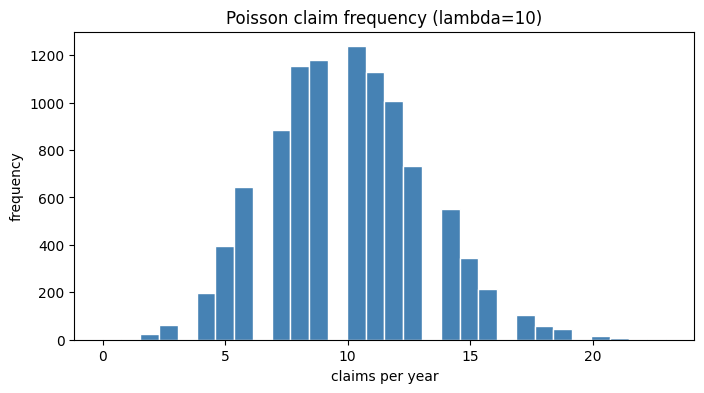

mean: 9.99
variance: 9.86


In [42]:
# Poisson Frequency Simulation
lambda_ = 10  # expected claims per year
n_simulations = 10000

poisson_claims = np.random.poisson(lambda_, size=n_simulations)

plt.figure(figsize=(8, 4))
plt.hist(poisson_claims, bins=30, color='steelblue', edgecolor='white')
plt.title('Poisson claim frequency (lambda=10)')
plt.xlabel('claims per year')
plt.ylabel('frequency')
plt.show()

print('mean:', round(poisson_claims.mean(), 2))
print('variance:', round(poisson_claims.var(), 2))

## Poisson — Results

Mean and variance both came out around 10.
This confirms the key Poisson property: mean = variance.

Most simulated years fell between 6 and 14 claims,
with extreme values rarely appearing beyond 20.

One limitation: real insurance portfolios often show
higher variance than mean (overdispersion).
Poisson can't handle this, which motivates the next model.

## 2. Negative Binomial — claim frequency

Extension of Poisson that allows variance > mean.

- r = shape parameter
- p = success probability

Poisson forces mean = variance, which rarely holds
in real data. Negative Binomial is more realistic.

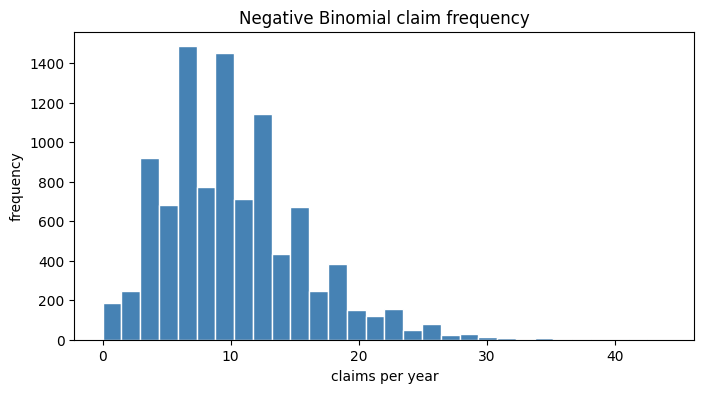

mean: 10.23
variance: 31.16


In [41]:
r = 5
p = 0.33
n_simulations = 10000

nb_claims = np.random.negative_binomial(r, p, size=n_simulations)

plt.figure(figsize=(8, 4))
plt.hist(nb_claims, bins=30, color='steelblue', edgecolor='white')
plt.title('Negative Binomial claim frequency')
plt.xlabel('claims per year')
plt.ylabel('frequency')
plt.show()

print('mean:', round(nb_claims.mean(), 2))
print('variance:', round(nb_claims.var(), 2))

## Negative Binomial — Results

Mean came out around 10, similar to Poisson.
Variance is around 31 — much higher than the mean.

This spread is visible in the histogram.
The distribution is wider and has a longer right tail.

For portfolios where claim counts vary significantly
year to year, this is a better fit than Poisson.

## 3. Comparing Poisson and Negative Binomial

Same mean, very different variance.
Poisson is too narrow for most real portfolios.

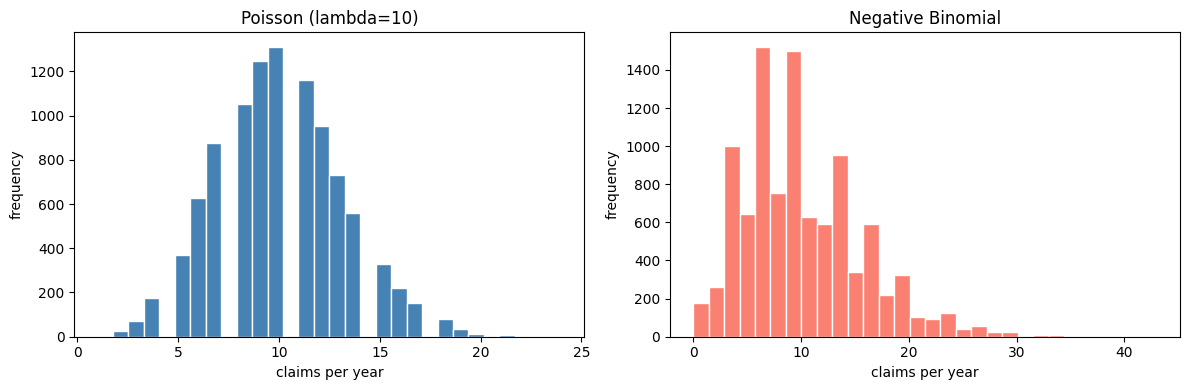

Poisson    — mean: 10.06 | variance: 9.91
Neg Binom  — mean: 10.16 | variance: 31.16


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(poisson_claims, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Poisson (lambda=10)')
axes[0].set_xlabel('claims per year')
axes[0].set_ylabel('frequency')

axes[1].hist(nb_claims, bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Negative Binomial')
axes[1].set_xlabel('claims per year')
axes[1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

print('Poisson    — mean:', round(poisson_claims.mean(), 2), '| variance:', round(poisson_claims.var(), 2))
print('Neg Binom  — mean:', round(nb_claims.mean(), 2), '| variance:', round(nb_claims.var(), 2))

## Comparison — Results

Poisson and Negative Binomial have similar means,
but very different variances.

Poisson:      mean ≈ 10, variance ≈ 10
N.B.:         mean ≈ 10, variance ≈ 31

Negative Binomial fits better when claim counts
vary significantly across years.

## 4. Severity Models

Models the size of each individual claim.
Always positive, typically right-skewed.

Three distributions:
- Lognormal: standard choice for most claim types
- Gamma: flexible alternative
- Pareto: heavy tail, used for extreme losses

## 4.1 Lognormal Severity

Standard choice for modelling individual claim sizes.

- mu = mean of log(X)
- sigma = standard deviation of log(X)

Right-skewed distribution — most claims are small,
but occasional large losses pull the tail out.
Common for motor and property claims.

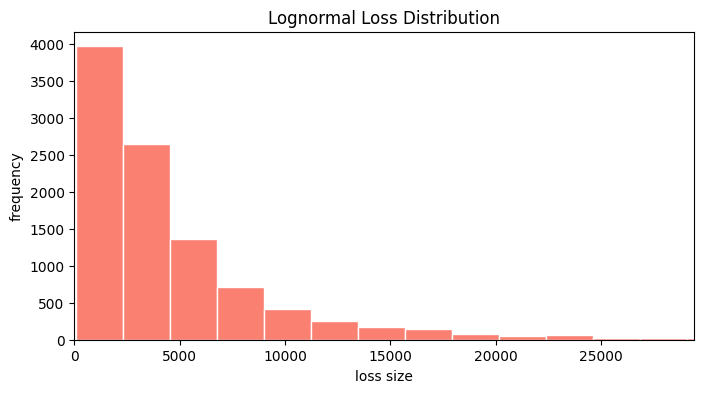

mean: 4853.66
variance: 35809299.58


In [ ]:
## 4.1 Lognormal Severity

mu = 8        # log-scale mean
sigma = 1.0   # log-scale std
n_simulations = 10000

lognormal_losses = np.random.lognormal(mean=mu, sigma=sigma, size=n_simulations)

plt.figure(figsize=(8,4))
plt.hist(lognormal_losses, bins=50, color='salmon', edgecolor='white')
plt.title('Lognormal Loss Distribution')
plt.xlabel('loss size')
plt.ylabel('frequency')
plt.xlim(0, np.percentile(lognormal_losses, 99))  # extreme cut for visibility
plt.show()

print('mean:', round(lognormal_losses.mean(),ㄴ2))
print('variance:', round(lognormal_losses.var(),2))

## Lognormal — Results

Mean and variance reflect the right skew.
Most losses are clustered near the lower end,
with a long tail extending to the right.

## 4.2 Gamma Severity

Flexible alternative to Lognormal.

- shape = controls the form of the distribution
- scale = controls the spread (mean = shape * scale)

Less heavy tail than Lognormal.
Often used for medical or short-tail lines.

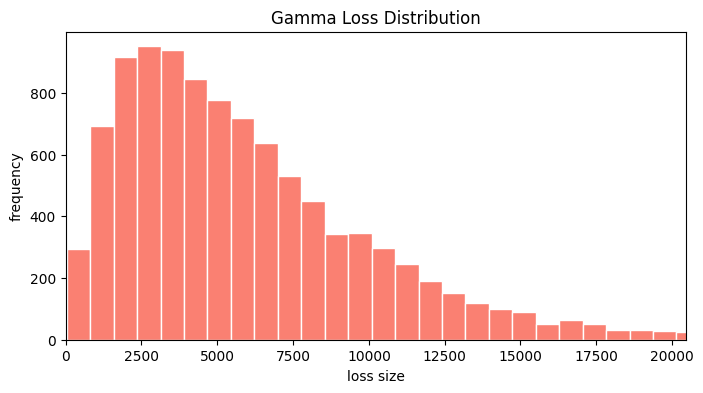

mean: 6023.84
variance: 18695510.68


In [33]:
## 4.2 Gamma Severity

shape = 2.0
scale = 3000   # 평균 = shape * scale

gamma_losses = np.random.gamma(shape, scale, size=n_simulations)

plt.figure(figsize=(8,4))
plt.hist(gamma_losses, bins=50, color='salmon', edgecolor='white')
plt.title('Gamma Loss Distribution')
plt.xlabel('loss size')
plt.ylabel('frequency')
plt.xlim(0, np.percentile(gamma_losses, 99))
plt.show()

print('mean:', round(gamma_losses.mean(),2))
print('variance:', round(gamma_losses.var(),2))

## Gamma — Results

Similar shape to Lognormal but lighter tail.
Mean = shape * scale = 2 * 3000 = 6000.

## 4.3 Pareto Severity — Heavy Tail

Used for extreme losses where large claims
are more likely than Lognormal suggests.

- alpha = tail index. Lower alpha = heavier tail.
- xm = minimum possible loss

Key property: variance can be infinite when alpha <= 2.
This makes it the most conservative severity model.

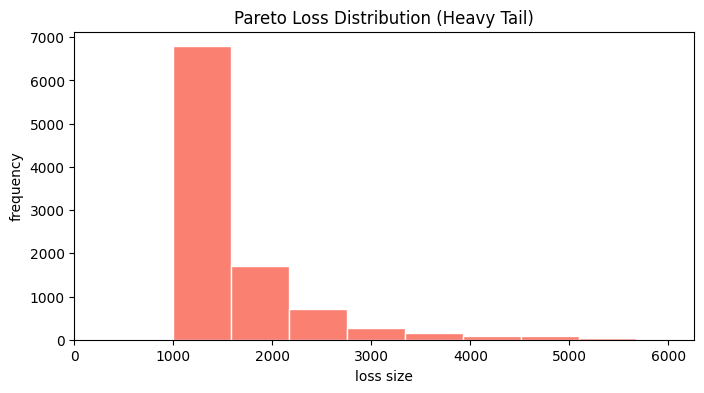

mean: 1670.35
variance: 1677185.21


In [39]:
## 4.3 Pareto Severity (Heavy Tail)

alpha = 2.5   # tail parameter
xm = 1000     # minimum loss

pareto_losses = (np.random.pareto(alpha, n_simulations) + 1) * xm

plt.figure(figsize=(8,4))
plt.hist(pareto_losses, bins=100, color='salmon', edgecolor='white')
plt.title('Pareto Loss Distribution (Heavy Tail)')
plt.xlabel('loss size')
plt.ylabel('frequency')
plt.xlim(0, np.percentile(pareto_losses, 99))
plt.show()

print('mean:', round(pareto_losses.mean(),2))
print('variance:', round(pareto_losses.var(),2))

## Pareto — Results

Distribution is highly concentrated near xm,
with a very long right tail.

This is the heavy tail property — rare but
extreme losses dominate the risk profile.
Critical for catastrophe and liability lines.